<center><image src="https://drive.google.com/uc?id=1n3G4TdK_u6PQHcLrxB_A0HijNdigXmUH">

<h3 style="text-align: center;"><b>Школа глубокого обучения ФПМИ МФТИ</b></h3>

<h3 style="text-align: center;"><b>Домашнее задание. Сегментация изображений</b></h3>


В этом задании вам предстоит решить задачу сегментации медицинских снимков. Домашнее задание можно разделить на следующие части:

* Построй свой первый бейзлайн! [6]
  * BCE Loss [2]
  * SegNet [2]
  * Train [1]
  * Test [1]
* Мир других лоссов! [2]
  * Dice Loss [1]
  * Focal Loss [1]
  * BONUS: лосс из статьи [5]
* Новая модель! [2]
  * UNet [2]


**Максимальный балл:** 10 баллов.

Также для студентов желающих еще более углубиться в задачу предлагается решить бонусное задание, которое даст дополнительные 5 баллов. BONUS задание необязательное.


# Шаг 1. Загрузка и подготовка данных

1. Для начала мы скачаем датасет: [ADDI project](https://www.fc.up.pt/addi/ph2%20database.html).

<table><tr><td>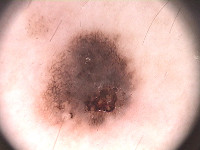</td><td>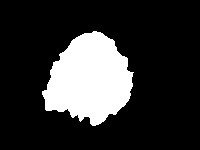</td></tr></table>

2. Разархивируем .rar файл.
3. Обратите внимание, что папка  `PH2 Dataset images` должна лежать там же где и ipynb notebook.

Это фотографии двух типов **поражений кожи:** меланома и родинки.
В данном задании мы не будем заниматься их классификацией, а будем **сегментировать** их.

In [30]:
!gdown 1T_RPkPP0jeWwK8L1UrmBw8V30eD7v6Ql

Downloading...
From (original): https://drive.google.com/uc?id=1T_RPkPP0jeWwK8L1UrmBw8V30eD7v6Ql
From (redirected): https://drive.google.com/uc?id=1T_RPkPP0jeWwK8L1UrmBw8V30eD7v6Ql&confirm=t&uuid=1202a688-2a01-462e-820f-f19f71896e53
To: /content/PH2Dataset.rar
100% 162M/162M [00:01<00:00, 81.1MB/s]


In [31]:
get_ipython().system_raw("unrar x PH2Dataset.rar")

Стуктура датасета у нас следующая:

    IMD_002/
        IMD002_Dermoscopic_Image/
            IMD002.bmp
        IMD002_lesion/
            IMD002_lesion.bmp
        IMD002_roi/
            ...
    IMD_003/
        ...
        ...

 Здесь `X.bmp` — изображение, которое нужно сегментировать, `X_lesion.bmp` — результат сегментации.

Для загрузки датасета можно использовать skimage: [`skimage.io.imread()`](https://scikit-image.org/docs/dev/api/skimage.io.html)

In [32]:
images = []
lesions = []
from skimage.io import imread
import os
root = 'PH2Dataset'

for root, dirs, files in os.walk(os.path.join(root, 'PH2 Dataset images')):
    if root.endswith('_Dermoscopic_Image'):
        images.append(imread(os.path.join(root, files[0])))
    if root.endswith('_lesion'):
        lesions.append(imread(os.path.join(root, files[0])))

Изображения имеют разные размеры. Давайте изменим их размер на $256\times256 $ пикселей. Для изменения размера изображений можно использовать [`skimage.transform.resize()`](https://scikit-image.org/docs/dev/api/skimage.transform.html#skimage.transform.resize).
Эта функция также автоматически нормализует изображения в диапазоне $[0,1]$.


In [33]:
from skimage.transform import resize
size = (256, 256)
X = [resize(x, size, mode='constant', anti_aliasing=True,) for x in images]
Y = [resize(y, size, mode='constant', anti_aliasing=False) > 0.5 for y in lesions]

In [34]:
import numpy as np
X = np.array(X, np.float32)
Y = np.array(Y, np.float32)
print(f'Loaded {len(X)} images')

Loaded 200 images


Чтобы убедиться, что все корректно, мы нарисуем несколько изображений

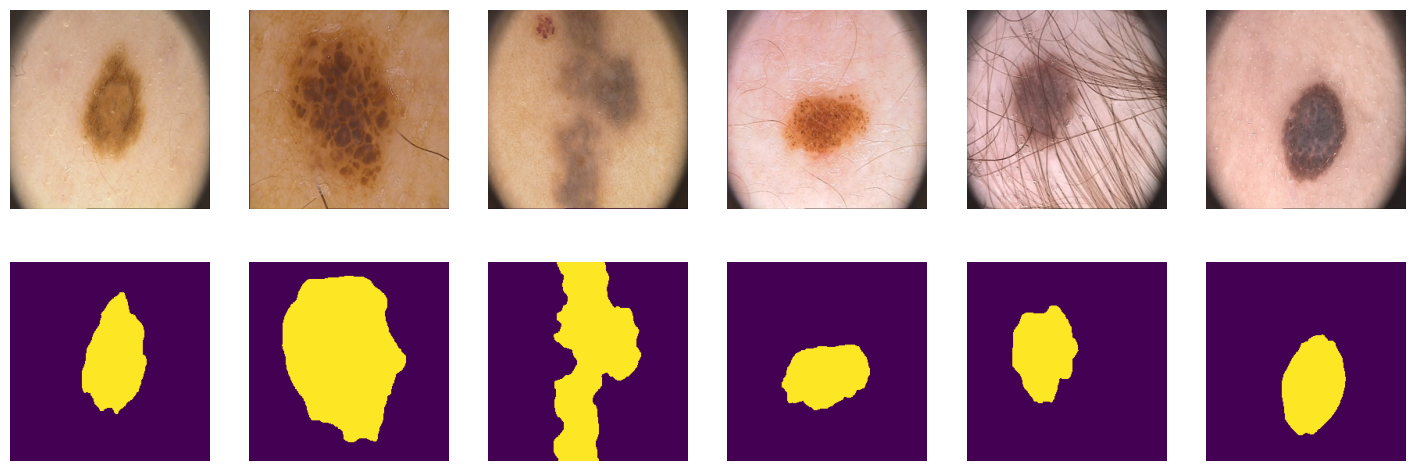

In [35]:
import matplotlib.pyplot as plt
from IPython.display import clear_output

plt.figure(figsize=(18, 6))
for i in range(6):
    plt.subplot(2, 6, i+1)
    plt.axis("off")
    plt.imshow(X[i])

    plt.subplot(2, 6, i+7)
    plt.axis("off")
    plt.imshow(Y[i])
plt.show();

Разделим наши 200 картинок на 100/50/50
 для обучения, валидации и теста соответственно

In [36]:
ix = np.random.choice(len(X), len(X), False)
tr, val, ts = np.split(ix, [100, 150])

In [37]:
print(len(tr), len(val), len(ts))

100 50 50


## PyTorch DataLoader

In [38]:
from torch.utils.data import DataLoader
batch_size = 25
train_dataloader = DataLoader(list(zip(np.rollaxis(X[tr], 3, 1), Y[tr, np.newaxis])),
                     batch_size=batch_size, shuffle=True)
valid_dataloader = DataLoader(list(zip(np.rollaxis(X[val], 3, 1), Y[val, np.newaxis])),
                      batch_size=batch_size, shuffle=False)
test_dataloader = DataLoader(list(zip(np.rollaxis(X[ts], 3, 1), Y[ts, np.newaxis])),
                     batch_size=batch_size, shuffle=False)

In [39]:
import torch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


# Шаг 2. Метрика качества модели

## IoU (intersection over union)

В данном разделе предлагается использовать следующую метрику для оценки качества:

$I o U=\frac{\text {target } \cap \text { prediction }}{\text {target } \cup{prediction }}$

Пересечение (A ∩ B) состоит из пикселей, найденных как в маске предсказания, так и в основной маске истины, тогда как объединение (A ∪ B) просто состоит из всех пикселей, найденных либо в маске предсказания, либо в целевой маске.


Что будет являться пересением и объединением в задаче сегментации?

Давайте разберем следующий пример:





<p style="align: center;"><img align=center src="https://drive.google.com/uc?export=view&id=1rBYFgli48AUUN9idiyq8j3J5DboB93yN" width=1000 height=800/></p>

In [ ]:
# !pip install torchmetrics

In [14]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [3]:
from torchmetrics import JaccardIndex

iou_score = JaccardIndex(threshold=0.5, task="binary", average='none').to(device)

# Задания: Построй свой первый бейзлайн!

Итак, загрузка файлов, код датасета и даталоадера написана за вас. Метрика IoU написана за вас! Вам остается написать лосс, модель и функции обучения и теста модели.

* Построй свой первый бейзлайн! [6]
  * BCE Loss [2]
  * SegNet [2]
  * Train [1]
  * Test [1]

## Шаг 3. Loss функция - BCE [2 балла]

Популярным лоссом для бинарной сегментации является *бинарная кросс-энтропия*, которая задается следующим образом:

$$\mathcal L_{BCE}(y, \hat y) = -\sum_i \left[y_i\log\sigma(\hat y_i) + (1-y_i)\log(1-\sigma(\hat y_i))\right] \space [1]$$

где $y$ это  таргет желаемого результата и $\hat y$ является выходом модели. $\sigma$ - это [*логистическая* функция](https://en.wikipedia.org/wiki/Sigmoid_function), который преобразует действительное число $\mathbb R$ в вероятность $[0,1]$.

Однако эта потеря страдает от проблем численной нестабильности. Самое главное, что $\lim_{x\rightarrow0}\log(x)=\infty$ приводит к неустойчивости в процессе оптимизации. Рекомендуется посмотреть следующее [упрощение](https://www.tensorflow.org/api_docs/python/tf/nn/sigmoid_cross_entropy_with_logits). Эта функция эквивалентна первой и не так подвержена численной неустойчивости:

$$\mathcal L_{BCE} = \hat y - y\hat y + \log\left(1+\exp(-\hat y)\right) \space [2]$$

### Вывод численно стабильной формулы BCE лосса [1 балл]



Выведите из формулы [1] формулу [2]:

$$\mathcal L_{BCE}(y, \hat y) = -\sum_i \left[y_i\log\sigma(\hat y_i) + (1-y_i)\log(1-\sigma(\hat y_i))\right] \space [1]$$

$$\mathcal L_{BCE} = \hat y - y\hat y + \log\left(1+\exp(-\hat y)\right) \space [2]$$

Не забываем, что здесь $\hat y_i$ - это логиты сети, не вероятности и не лейблы.

**Ответ:**

Пусть z = ŷ — логит модели, а σ(z) = 1 / (1 + exp(-z)).

Исходная формула BCE:

L = -[y log(σ(z)) + (1 - y) log(1 - σ(z))]

Так как:

log(σ(z)) = -log(1 + exp(-z))

и

log(1 - σ(z)) = -z - log(1 + exp(-z)),

то:

L = -[y · (-log(1 + exp(-z))) + (1 - y) · (-z - log(1 + exp(-z)))]

Раскрываем скобки:

L = y log(1 + exp(-z)) + (1 - y)z + (1 - y)log(1 + exp(-z))

Складываем части с log:

L = (y + 1 - y)log(1 + exp(-z)) + z - yz

Итог:

L = z - yz + log(1 + exp(-z))

То есть:

L_BCE = ŷ - yŷ + log(1 + exp(-ŷ))

### Реализуйте в коде оба варианта лосса [1 балл]

Реализуйте следующие функции:

*   `bce_true()` - честная прямая реализация лосса с формулой $$\mathcal L_{BCE}(y, \hat y) = -\sum_i \left[y_i\log\sigma(\hat y_i) + (1-y_i)\log(1-\sigma(\hat y_i))\right].$$
*   `bce_loss()` - реализация формулы, которую мы вывели $$\mathcal L_{BCE} = \hat y - y\hat y + \log\left(1+\exp(-\hat y)\right).$$

И сравните результаты функций с реализацией Pytorch:
*   `bce_torch()`
*   `bce_torch_with_logits()`

In [4]:
import torch.nn.functional as F
import torch.nn as nn

In [5]:
bce_torch = nn.BCELoss(reduction='sum') # (sigmoid(y_pred), y_real)
bce_torch_with_logits = nn.BCEWithLogitsLoss(reduction='sum')

In [6]:
def bce_loss(y_pred, y_real):
    y_real = y_real.to(torch.float)

    loss = torch.clamp(y_pred, min=0) - y_pred * y_real + torch.log(1 + torch.exp(-torch.abs(y_pred)))

    return loss.sum()


def bce_true(y_pred, y_real):
    y_real = y_real.to(torch.float)
    eps = 1e-8

    y_prob = torch.sigmoid(y_pred)

    loss = -(y_real * torch.log(y_prob + eps) + (1 - y_real) * torch.log(1 - y_prob + eps))

    return loss.sum()

Проверим корректность работы на простом примере

In [7]:
y_pred = torch.randn(3, 2, requires_grad=False)
y_true = torch.rand(3, 2, requires_grad=False)

print(f'BCE loss from scratch bce_loss             = {bce_loss(y_pred, y_true)}')
print(f'BCE loss честно посчитанный                = {bce_true(y_pred, y_true)}')
print(f'BCE loss from torch bce_torch              = {bce_torch(torch.sigmoid(y_pred), y_true)}')
print(f'BCE loss from torch with logits bce_torch  = {bce_torch_with_logits(y_pred, y_true)}')


BCE loss from scratch bce_loss             = 4.087818145751953
BCE loss честно посчитанный                = 4.087818145751953
BCE loss from torch bce_torch              = 4.087818145751953
BCE loss from torch with logits bce_torch  = 4.087818145751953


Инструкции `assert` в Python — это булевы выражения, которые проверяют, является ли условие истинным (`True`). Внизу в коде мы проверяем функция `bce_loss()` выдает тот же результат, что и функция из Pytorch или нет. Если равенства не будет, что будет означать, что результаты функций не совпадают, а значит вы неправильно реализовали фукнцию `bce_loss()`, `assert` возвратит ошибку.

Функция `numpy.isclose()` используется для сравнения двух чисел с учётом допустимой погрешности. Она особенно полезна при работе с числами с плавающей точкой, где точное сравнение может быть проблематичным из-за ограничений представления таких чисел в компьютере.

Как она работает?

`numpy.isclose(a, b, rtol=1e-05, atol=1e-08) `принимает два числа (`a` и `b`) и сравнивает их, учитывая относительную и абсолютную погрешность. Если разница между двумя числами меньше заданного порога, функция возвращает `True`, иначе — `False`.

Параметры:

    rtol: Относительная погрешность (по умолчанию 1e-05). Используется для определения разницы относительно большего значения.
    atol: Абсолютная погрешность (по умолчанию 1e-08). Определяет минимальную разницу, которую следует учитывать.

Мы будем использовать `assert` и `numpy.isclose()` для проверки корректности нашего кода.

In [8]:
assert np.isclose(bce_loss(y_pred, y_true), bce_torch(torch.sigmoid(y_pred), y_true))
assert np.isclose(bce_loss(y_pred, y_true), bce_torch_with_logits(y_pred, y_true))
assert np.isclose(bce_true(y_pred, y_true), bce_torch(torch.sigmoid(y_pred), y_true))
assert np.isclose(bce_true(y_pred, y_true), bce_torch_with_logits(y_pred, y_true))

Давайте теперь посчитаем на простом примере, но с теми же размерностями, что и в датасете

In [9]:
y_pred = torch.randn((2, 1, 3, 3), requires_grad=False)
y_true = torch.randint(0, 2, (2, 1, 3, 3))

print(f'BCE loss from scratch bce_loss            = {bce_loss(y_pred, y_true)}')
print(f'BCE loss честно посчитанный               = {bce_true(y_pred, y_true)}')
print(f'BCE loss from torch bce_torch             = {bce_torch(torch.sigmoid(y_pred), y_true.to(torch.float))}')
print(f'BCE loss from torch with logits bce_torch = {bce_torch_with_logits(y_pred, y_true.to(torch.float))}')

BCE loss from scratch bce_loss            = 17.702938079833984
BCE loss честно посчитанный               = 17.702938079833984
BCE loss from torch bce_torch             = 17.702938079833984
BCE loss from torch with logits bce_torch = 17.702938079833984


In [10]:
assert np.isclose(bce_loss(y_pred, y_true), bce_torch(torch.sigmoid(y_pred), y_true.to(torch.float)))
assert np.isclose(bce_loss(y_pred, y_true), bce_torch_with_logits(y_pred, y_true.to(torch.float)))
assert np.isclose(bce_true(y_pred, y_true), bce_torch(torch.sigmoid(y_pred), y_true.to(torch.float)))
assert np.isclose(bce_true(y_pred, y_true), bce_torch_with_logits(y_pred, y_true.to(torch.float)))

Давайте посчитаем на реальных логитах и сегментационной маске:

In [11]:
!gdown --folder 1EX0RW1TRQVkLmR1h6miCQqyhYPFyg28M

Retrieving folder contents
Processing file 1--WxvBdpMn_NOmYPf3a4au8MHzfx5baC labels.pt
Processing file 1-0A7_CS_vKiSCkgIDJ4joThCEcFedA3I logits.pt
Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1--WxvBdpMn_NOmYPf3a4au8MHzfx5baC
To: /content/for_asserts/labels.pt
100% 1.18k/1.18k [00:00<00:00, 5.27MB/s]
Downloading...
From: https://drive.google.com/uc?id=1-0A7_CS_vKiSCkgIDJ4joThCEcFedA3I
To: /content/for_asserts/logits.pt
100% 1.18k/1.18k [00:00<00:00, 6.76MB/s]
Download completed


In [12]:
path_to_dummy_samples = '/content/for_asserts'
dummpy_sample = {'logits': torch.load(f'{path_to_dummy_samples}/logits.pt'),
                 'labels': torch.load(f'{path_to_dummy_samples}/labels.pt')}
dummpy_sample['labels'] = dummpy_sample['labels'].to(device)
dummpy_sample['logits'] = dummpy_sample['logits'].to(device)

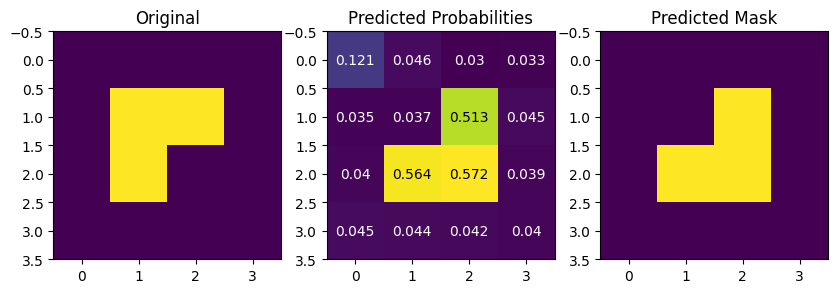

In [15]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize= (10,3*10))

ax1.imshow(dummpy_sample['labels'].squeeze(1)[0].cpu())
ax1.set_title("Original")

ax2.imshow(dummpy_sample['logits'].sigmoid().squeeze(1)[0].cpu())
for (j,i),label in np.ndenumerate(dummpy_sample['logits'].sigmoid().squeeze(1)[0].cpu()):
    if label < 0.5:
        color = 'white'
    else:
        color = 'black'
    ax2.text(i,j,round(label,3), color=color, ha='center',va='center')

ax2.set_title("Predicted Probabilities")

ax3.imshow((dummpy_sample['logits'].sigmoid() > 0.5).squeeze(1)[0].cpu())
ax3.set_title("Predicted Mask")
plt.show()

Проверяем на данном примере:

In [16]:
bce_loss_score = bce_loss(dummpy_sample['logits'].cpu(), dummpy_sample['labels'].cpu())
bce_true_score = bce_true(dummpy_sample['logits'].cpu(), dummpy_sample['labels'].cpu())
bce_torch_score = bce_torch(torch.sigmoid(dummpy_sample['logits'].cpu()), dummpy_sample['labels'].cpu().float())
bce_torch_with_logits_score = bce_torch_with_logits(dummpy_sample['logits'].cpu(), dummpy_sample['labels'].cpu().float())
assert np.isclose(bce_loss_score, bce_torch_score)
assert np.isclose(bce_loss_score, bce_torch_with_logits_score)
assert np.isclose(bce_true_score, bce_torch_score)
assert np.isclose(bce_true_score, bce_torch_with_logits_score)

## Шаг 4. Модель SegNet [2 балла]

Ваше задание здесь состоит в том, чтобы реализовать SegNet архитектуру.

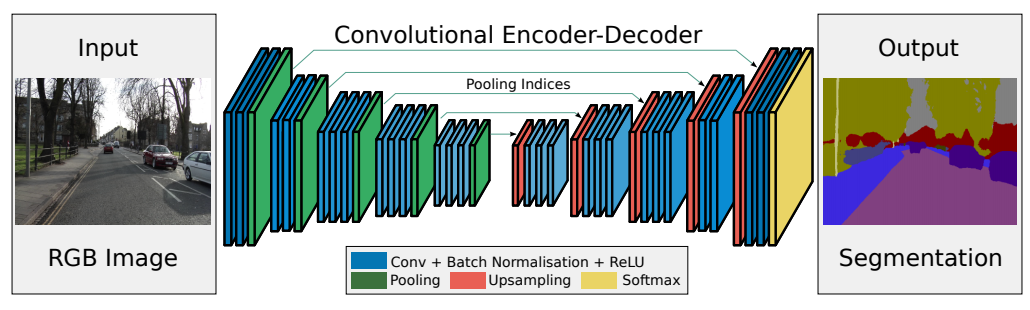

* Badrinarayanan, V., Kendall, A., & Cipolla, R. (2015). [SegNet: A deep convolutional
encoder-decoder architecture for image segmentation](https://arxiv.org/pdf/1511.00561.pdf)

In [17]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models
import torch.optim as optim
from time import time

from matplotlib import rcParams
rcParams['figure.figsize'] = (15,4)

Внимательно посмотрите из чего состоит модель и для чего выбраны те или иные блоки. Для этого скачаем и изучим feature extractor VGG-16, который лежит в основе SegNet.

In [18]:
model_vgg16 = models.vgg16(weights = models.VGG16_Weights.IMAGENET1K_V1)

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:07<00:00, 71.5MB/s]


In [19]:
model_vgg16

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

Feature extractor VGG-16 состоит из 5 блоков:
- два блока со структурой:
Conv2d -> ReLU -> Conv2d -> ReLU -> MaxPool2d
- три блока со структурой:
Conv2d -> ReLU -> Conv2d -> ReLU -> Conv2d -> ReLU -> MaxPool2d

В первом блоке - на входе три канала (по числу каналов в изображениях), которые конволюционный слой преобразует в 64 канала.

Во втором, третьем и четвертом блоках первый конволюционный слой удваивает количество каналов, а последующие конволюционные слои не меняют количество каналов.

В последнем блоке число каналов от слоя к слою не меняется.

Теперь напишем код одного блока энкодера нашей модели SegNet.  

In [20]:
# Параметрами блока будут:
# - количество каналов на входе
# - количество каналов на выходе
# - глубина блока (2 или 3, по количеству конволюционных слоев)
# - kernel_size и padding
#
class EncoderBlock(nn.Module):
    def __init__(self, in_channels, out_channels, depth, kernel_size = 3, padding = 1):
        super(EncoderBlock, self).__init__() # инициируем экземляр класса, наследующего от nn.Module
        self.layers = nn.ModuleList() # в self.layers будем добавлять слои блока
        # дальше реализуем то, что на картинке выше обозначено Conv + Batch Normalization + ReLU
        self.layers.append(nn.Conv2d(in_channels = in_channels, out_channels = out_channels, kernel_size = kernel_size, padding = padding))
        self.layers.append(nn.BatchNorm2d(out_channels))
        self.layers.append(nn.ReLU(inplace=True))

        # цикл for помогает использовать один код для блоков как с глубиной 2, так и с глубиной 3
        for i in range(depth-1):
            self.layers.append(nn.Conv2d(in_channels = out_channels, out_channels = out_channels, kernel_size = kernel_size, padding = padding))
            self.layers.append(nn.BatchNorm2d(out_channels))
            self.layers.append(nn.ReLU(inplace=True))

        self.maxpooling = nn.MaxPool2d(kernel_size=2, stride=2, return_indices=True) #добавляем MaxPool с индексами для последующего Unpooling

    # Обратите внимание: на вход метод forward() получает карту признаков (х),
    # а возвращает карту признаков и индексы для последующего Unpooling
    def forward(self, x):
        for layer in self.layers:
            x = layer(x)
        x, indices = self.maxpooling(x)
        return x, indices


По аналогии напишите код одного блока декодера.

К карте признаков на входе каждого блока примеяется nn.MaxUnpool2d с индексами из симметричного блока энкодера. Затем повторяется связка Conv + Batch Normalization + ReLU. Количество каналов меняется зеркально блокам энкодера:
- в первом блоке декодера количество каналов не меняется
- во 2-4 блоках декодера количество каналов уменьшается в 2 раза после прохождения последнего конволюционного слоя
- на выходе из последнего блока декодера 1 канал

Обратите внимание, что после последней конволюции последнего блока декодера не применяется батч-нормализация и функция активации.

In [21]:
class DecoderBlock(nn.Module):
    def __init__(self, in_channels, out_channels, depth, kernel_size=3, padding=1, final=False):
        super(DecoderBlock, self).__init__()

        self.unpooling = nn.MaxUnpool2d(kernel_size=2, stride=2)
        self.layers = nn.ModuleList()

        # Первые conv-слои: количество каналов пока не меняем
        for i in range(depth - 1):
            self.layers.append(
                nn.Conv2d(
                    in_channels=in_channels,
                    out_channels=in_channels,
                    kernel_size=kernel_size,
                    padding=padding
                )
            )
            self.layers.append(nn.BatchNorm2d(in_channels))
            self.layers.append(nn.ReLU(inplace=True))

        # Последняя conv: здесь меняем число каналов
        self.layers.append(
            nn.Conv2d(
                in_channels=in_channels,
                out_channels=out_channels,
                kernel_size=kernel_size,
                padding=padding
            )
        )

        # В последнем блоке SegNet не ставим BatchNorm и ReLU после последней conv
        if not final:
            self.layers.append(nn.BatchNorm2d(out_channels))
            self.layers.append(nn.ReLU(inplace=True))

    def forward(self, x, indices):
        x = self.unpooling(x, indices)

        for layer in self.layers:
            x = layer(x)

        return x

Соединим блоки энкодера и декодера в модель SegNet:

In [22]:
class SegNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1, num_features=64) -> None:
        super(SegNet, self).__init__()

        # Encoder
        self.encoder0 = EncoderBlock(in_channels, num_features, depth=2)
        self.encoder1 = EncoderBlock(num_features, num_features * 2, depth=2)
        self.encoder2 = EncoderBlock(num_features * 2, num_features * 4, depth=3)
        self.encoder3 = EncoderBlock(num_features * 4, num_features * 8, depth=3)

        # Encoder bottleneck: количество каналов не меняется
        self.encoder4 = EncoderBlock(num_features * 8, num_features * 8, depth=3)

        # Decoder bottleneck
        self.decoder0 = DecoderBlock(num_features * 8, num_features * 8, depth=3)

        # Decoder
        self.decoder1 = DecoderBlock(num_features * 8, num_features * 4, depth=3)
        self.decoder2 = DecoderBlock(num_features * 4, num_features * 2, depth=3)
        self.decoder3 = DecoderBlock(num_features * 2, num_features, depth=2)
        self.decoder4 = DecoderBlock(num_features, out_channels, depth=2, final=True)

    def forward(self, x):
        # Encoder
        x, indices0 = self.encoder0(x)
        x, indices1 = self.encoder1(x)
        x, indices2 = self.encoder2(x)
        x, indices3 = self.encoder3(x)
        x, indices4 = self.encoder4(x)

        # Decoder
        x = self.decoder0(x, indices4)
        x = self.decoder1(x, indices3)
        x = self.decoder2(x, indices2)
        x = self.decoder3(x, indices1)
        output = self.decoder4(x, indices0)

        return output  # no activation

In [24]:
segnet_model = SegNet().to(device)

x_test = torch.randn(2, 3, 256, 256).to(device)
out = segnet_model(x_test)

print(out.shape)

torch.Size([2, 1, 256, 256])


## Шаг 5. Тренировка модели [1 балл]

Напишите функции для обучения модели.

In [23]:
from tqdm.notebook import tqdm

In [25]:
def compute_iou_from_logits(logits, labels, threshold=0.5, eps=1e-8):
    probs = torch.sigmoid(logits)
    preds = (probs > threshold).float()
    labels = labels.float()

    intersection = (preds * labels).sum(dim=(1, 2, 3))
    union = ((preds + labels) > 0).float().sum(dim=(1, 2, 3))

    iou = (intersection + eps) / (union + eps)
    return iou.mean()

In [26]:
def train(model, train_dataloader, valid_dataloader, loss_fn, optimizer, epochs=10, device=device):
    history = {
        "train_loss": [],
        "valid_loss": [],
        "train_iou": [],
        "valid_iou": []
    }

    best_iou = 0
    best_model_state = None

    for epoch in range(epochs):
        start_time = time()

        # TRAIN
        model.train()
        train_loss = 0
        train_iou = 0

        for images, masks in tqdm(train_dataloader, desc=f"Epoch {epoch + 1}/{epochs} train"):
            images = images.to(device).float()
            masks = masks.to(device).float()

            optimizer.zero_grad()

            logits = model(images)

            loss = loss_fn(logits, masks)
            loss_for_backward = loss / masks.numel()

            loss_for_backward.backward()
            optimizer.step()

            train_loss += loss_for_backward.item()
            train_iou += compute_iou_from_logits(logits.detach(), masks).item()

        train_loss /= len(train_dataloader)
        train_iou /= len(train_dataloader)

        # VALID
        model.eval()
        valid_loss = 0
        valid_iou = 0

        with torch.no_grad():
            for images, masks in tqdm(valid_dataloader, desc=f"Epoch {epoch + 1}/{epochs} valid"):
                images = images.to(device).float()
                masks = masks.to(device).float()

                logits = model(images)

                loss = loss_fn(logits, masks)
                loss = loss / masks.numel()

                valid_loss += loss.item()
                valid_iou += compute_iou_from_logits(logits, masks).item()

        valid_loss /= len(valid_dataloader)
        valid_iou /= len(valid_dataloader)

        history["train_loss"].append(train_loss)
        history["valid_loss"].append(valid_loss)
        history["train_iou"].append(train_iou)
        history["valid_iou"].append(valid_iou)

        if valid_iou > best_iou:
            best_iou = valid_iou
            best_model_state = model.state_dict().copy()
            torch.save(best_model_state, "best_segnet_bce.pth")

        print(
            f"Epoch {epoch + 1}/{epochs} | "
            f"train_loss: {train_loss:.4f} | "
            f"valid_loss: {valid_loss:.4f} | "
            f"train_iou: {train_iou:.4f} | "
            f"valid_iou: {valid_iou:.4f} | "
            f"time: {time() - start_time:.1f}s"
        )

    return history

Обучите модель **SegNet**. В качестве оптимайзера можно взять Adam.

In [40]:
segnet_model = SegNet().to(device)

optimizer = optim.Adam(segnet_model.parameters(), lr=1e-4)

segnet_bce_history = train(
    model=segnet_model,
    train_dataloader=train_dataloader,
    valid_dataloader=valid_dataloader,
    loss_fn=bce_loss,
    optimizer=optimizer,
    epochs=10,
    device=device
)

Epoch 1/10 train:   0%|          | 0/4 [00:00<?, ?it/s]

Epoch 1/10 valid:   0%|          | 0/2 [00:00<?, ?it/s]

Epoch 1/10 | train_loss: 0.6597 | valid_loss: 0.6857 | train_iou: 0.1951 | valid_iou: 0.0000 | time: 6.7s


Epoch 2/10 train:   0%|          | 0/4 [00:00<?, ?it/s]

Epoch 2/10 valid:   0%|          | 0/2 [00:00<?, ?it/s]

...

Epoch 9/10 valid:   0%|          | 0/2 [00:00<?, ?it/s]

Epoch 9/10 | train_loss: 0.2601 | valid_loss: 0.6248 | train_iou: 0.8103 | valid_iou: 0.1634 | time: 5.8s


Epoch 10/10 train:   0%|          | 0/4 [00:00<?, ?it/s]

Epoch 10/10 valid:   0%|          | 0/2 [00:00<?, ?it/s]

Epoch 10/10 | train_loss: 0.2370 | valid_loss: 0.4845 | train_iou: 0.8191 | valid_iou: 0.4449 | time: 5.7s


## Шаг 6. Инференс [1 балл]

После обучения модели напишите функцию теста, воспользуйтесь лучшим чекпоинтом и протестируйте работу модели на тестовой выборке.

In [41]:
def test(model, test_dataloader, loss_fn, device=device, checkpoint_path="best_segnet_bce.pth"):
    if checkpoint_path is not None:
        model.load_state_dict(torch.load(checkpoint_path, map_location=device))

    model.to(device)
    model.eval()

    test_loss = 0
    test_iou = 0

    images_for_show = None
    masks_for_show = None
    preds_for_show = None

    with torch.no_grad():
        for images, masks in tqdm(test_dataloader, desc="test"):
            images = images.to(device).float()
            masks = masks.to(device).float()

            logits = model(images)

            loss = loss_fn(logits, masks)
            loss = loss / masks.numel()

            test_loss += loss.item()
            test_iou += compute_iou_from_logits(logits, masks).item()

            if images_for_show is None:
                images_for_show = images.detach().cpu()
                masks_for_show = masks.detach().cpu()
                preds_for_show = (torch.sigmoid(logits).detach().cpu() > 0.5).float()

    test_loss /= len(test_dataloader)
    test_iou /= len(test_dataloader)

    print(f"test_loss: {test_loss:.4f} | test_iou: {test_iou:.4f}")

    # Визуализация нескольких примеров
    n = min(3, images_for_show.shape[0])

    fig, axes = plt.subplots(n, 3, figsize=(10, 4 * n))

    if n == 1:
        axes = np.expand_dims(axes, axis=0)

    for i in range(n):
        image = images_for_show[i].permute(1, 2, 0)
        mask = masks_for_show[i].squeeze()
        pred = preds_for_show[i].squeeze()

        axes[i, 0].imshow(image)
        axes[i, 0].set_title("Image")
        axes[i, 0].axis("off")

        axes[i, 1].imshow(mask, cmap="gray")
        axes[i, 1].set_title("True mask")
        axes[i, 1].axis("off")

        axes[i, 2].imshow(pred, cmap="gray")
        axes[i, 2].set_title("Predicted mask")
        axes[i, 2].axis("off")

    plt.show()

    return test_loss, test_iou

test:   0%|          | 0/2 [00:00<?, ?it/s]

test_loss: 0.5278 | test_iou: 0.4331


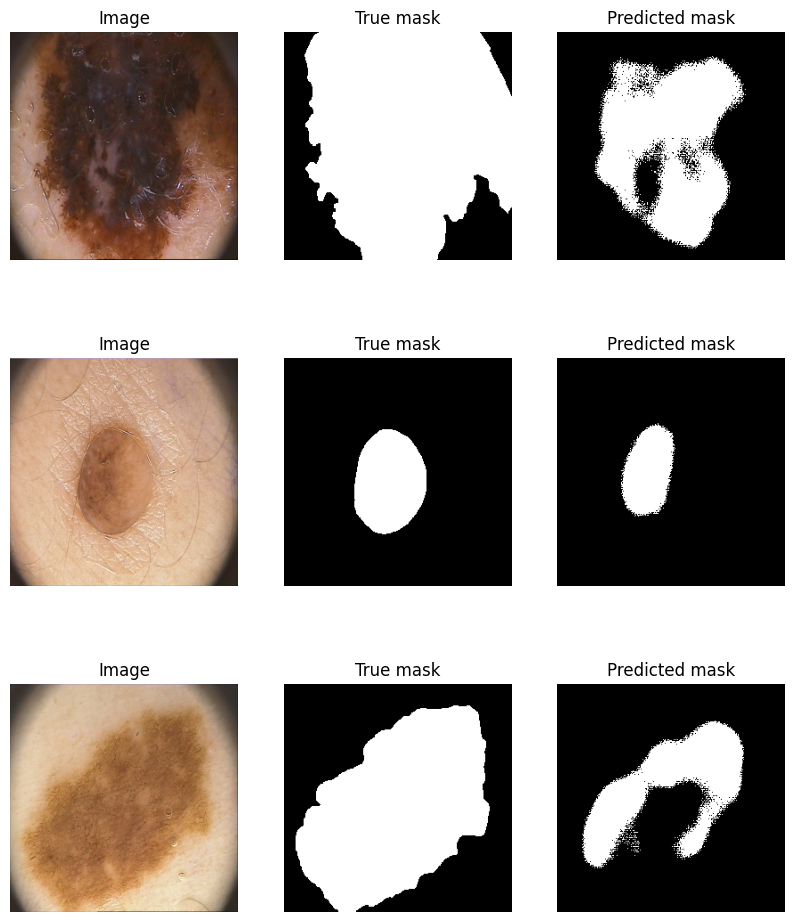

In [42]:
segnet_bce_test_loss, segnet_bce_test_iou = test(
    model=segnet_model,
    test_dataloader=test_dataloader,
    loss_fn=bce_loss,
    device=device,
    checkpoint_path="best_segnet_bce.pth"
)

# Задания: Мир других лоссов!

## Пробуем другие функции потерь [2 балла]

В данном разделе вам потребуется имплементировать две функции потерь: DICE и Focal loss.


### Dice Loss

**1. Dice coefficient:** Учитывая две маски $X$ и $Y$, общая метрика для измерения расстояния между этими двумя масками задается следующим образом:

$$D(X,Y)=\frac{2|X\cap Y|}{|X|+|Y|}$$

В терминах матрицы ошибок она будет считаться следующим образом:

$$D(X,Y) = \frac{2TP}{2TP + FP + FN}$$

Эта функция не является дифференцируемой, но это необходимое свойство для градиентного спуска. В данном случае мы можем приблизить его с помощью:

$$\mathcal L_D(X,Y) = 1- D(X, Y)$$

**Hints** (!):

1. Не забудьте подумать о численной нестабильности, возникающей в математической формуле при ситуации, когда $\frac{0}{0}$, т.е. вам нужно добавить очень маленькое число, например $\epsilon = 1e^{-8}$, в обе части дроби при подсчете $D(X,Y)$:

$$D(X,Y) = \frac{2TP + ϵ}{2TP + FP + FN + ϵ}$$

2. Dice метрика(!), не лосс, считается похожим образом как IoU:

    2.1. На вход вам приходят logits, т.е. значения от $-∞$ до $∞$. Их переводим в вероятности от 0 до 1 при помощи функции Sigmoid.

    2.2. Фиксируем порог, например threshold=0.5, и всему что ниже порога ставим значение 0, всему что выше 1. Получаем предсказанную маску из 0 и 1.

    2.3. Считаем TP, FP, FN

    2.4. Считаем DICE метрику по формуле

Вы можете прописать для себя функцию `dice_score()` и сравнить с результатами работы функции из библиотеки `torchmetrics`.

3. Но с метрикой есть проблема, что она не дифференцируема, и если вы захотите просто взять и прописать `dice_loss` = 1 - `dice_score`, Pytorch поругается на вас и скажет, что это недифференцируемая метрика. Чтобы посчитать dice_loss делаем следующие шаги:

    3.1. На вход вам приходят logits, т.е. значения от $-∞$ до $∞$. Их переводим в вероятности от 0 до 1 при помощи функции Sigmoid.

    3.2. Здесь нам уже не нужно фиксировать порог, мы просто работаем с вероятностями. Значения вероятностей дифференцируемы и через них будут протекать градиенты.

    3.3. Считаем TP, FP, FN также как и в Dice метрике, только вместо маски, подаем вероятности.

    3.4. Считаем DICE метрику по формуле

    3.5. Считаем лосс как Loss = 1 - DICE

Итак, давайте сначала пропишем dice_score.

In [ ]:
# !pip install -q gdown
# !gdown --folder 1EX0RWI1TRQVkLmR1h6miCQqyhYPFyg28M

Retrieving folder contents
Failed to retrieve folder contents


In [57]:
path_to_dummy_samples = '/content/for_asserts'

dummy_sample = {
    'logits': torch.load(f'{path_to_dummy_samples}/logits.pt'),
    'labels': torch.load(f'{path_to_dummy_samples}/labels.pt')
}

dummy_sample['labels'] = dummy_sample['labels'].to(device)
dummy_sample['logits'] = dummy_sample['logits'].to(device)

In [61]:
dummy_sample.keys()

dict_keys(['logits', 'labels'])

In [72]:
def dice_score(logits: torch.Tensor, labels: torch.Tensor, threshold: float = 0.5):
    '''
    Это именно метрика, не лосс.
    '''
    probs = torch.sigmoid(logits)

    score = dice(probs, labels.to(int))

    return score

In [73]:
from segmentation_models_pytorch.losses import DiceLoss

dice_loss_torch = DiceLoss(mode='binary')

assert torch.isclose(
    dice_loss_torch(dummy_sample['logits'], dummy_sample['labels'].to(int)),
    dice_loss(dummy_sample['logits'], dummy_sample['labels'])
)

Проверим на корректность функцию dice_score:

In [74]:
from torchmetrics.segmentation import DiceScore

dice = DiceScore(num_classes=1, average='micro').to(device)
dice(dummpy_sample['logits'].sigmoid(), dummpy_sample['labels'].to(int))

tensor(0.3158, device='cuda:0')

In [75]:
'''
если вы используете версию библиотеки 0.11.4, то можно взять torchmetrics.classification.Dice():

from torchmetrics.classification import Dice

dice = Dice(average='micro').to(device)

'''

"\nесли вы используете версию библиотеки 0.11.4, то можно взять torchmetrics.classification.Dice():\n\nfrom torchmetrics.classification import Dice\n\ndice = Dice(average='micro').to(device)\n\n"

In [76]:
assert torch.isclose(
    dice(dummy_sample['logits'].sigmoid(), dummy_sample['labels'].to(int)),
    dice_score(dummy_sample['logits'], dummy_sample['labels'])
)

Давайте теперь пропишем лосс и воспользуемся библиотекой `segmentation-models-pytorch`, чтобы убедиться в корректности нашей функции.

In [77]:
def dice_loss(logits: torch.Tensor, labels: torch.Tensor):
    '''
    Это лосс.
    '''
    eps = 1e-7

    probs = torch.sigmoid(logits)
    labels = labels.float()

    intersection = (probs * labels).sum()
    union = probs.sum() + labels.sum()

    dice = (2 * intersection + eps) / (union + eps)

    loss = 1 - dice
    return loss

Проверка на корректность:

In [78]:
# проверьте, что у вас установлена библиотека
#!pip install segmentation-models-pytorch

In [79]:
from segmentation_models_pytorch.losses import DiceLoss
dice_loss_torch = DiceLoss(mode='binary')
dice_loss_torch(dummpy_sample['logits'], dummpy_sample['labels'])

tensor(0.5756, device='cuda:0')

In [80]:
assert dice_loss_torch(dummpy_sample['logits'], dummpy_sample['labels'].to(int)) == dice_loss(dummpy_sample['logits'], dummpy_sample['labels'])

### Focal Loss

[**2. Focal loss:**](https://arxiv.org/pdf/1708.02002.pdf)

Окей, мы уже с вами умеем делать BCE loss:

$$\mathcal L_{BCE}(y, \hat y) = -\sum_i \left[y_i\log\sigma(\hat y_i) + (1-y_i)\log(1-\sigma(\hat y_i))\right].$$

Проблема с этой потерей заключается в том, что она имеет тенденцию приносить пользу классу **большинства** (фоновому) по отношению к классу **меньшинства** ( переднему). Поэтому обычно применяются весовые коэффициенты к каждому классу:

$$\mathcal L_{wBCE}(y, \hat y) = -\sum_i \alpha_i\left[y_i\log\sigma(\hat y_i) + (1-y_i)\log(1-\sigma(\hat y_i))\right].$$

Традиционно вес $\alpha_i$ определяется как обратная частота класса этого пикселя $i$, так что наблюдения миноритарного класса весят больше по отношению к классу большинства.


Из оригинальной статьи по [Focal Loss](https://arxiv.org/pdf/1708.02002.pdf):

$$p_t = \sigma(\hat y_i)y_i + (1 - \sigma(\hat y_i)) (1-y_i)$$

$$\mathcal L_{focal}(y, \hat y) = (1 - p_t)^{\gamma} \mathcal L_{BCE}(y_i, \hat y_i).$$

$$\mathcal L_{focal}(y, \hat y) = -\sum_i (1 - p_t)^{\gamma} \left[y_i\log\sigma(\hat y_i) + (1-y_i)\log(1-\sigma(\hat y_i))\right].$$

$$\mathcal L_{focal}(y, \hat y) = -\sum_i (1 - (\sigma(\hat y_i)y_i + (1 - \sigma(\hat y_i)) (1-y_i)))^{\gamma} \left[y_i\log\sigma(\hat y_i) + (1-y_i)\log(1-\sigma(\hat y_i))\right].$$

In [81]:
def focal_loss(y_real, y_pred, eps=1e-8, gamma=2):
    y_real = y_real.float()

    prob = torch.sigmoid(y_pred)

    pt = prob * y_real + (1 - prob) * (1 - y_real)

    bce = -(y_real * torch.log(prob + eps) + (1 - y_real) * torch.log(1 - prob + eps))

    loss = ((1 - pt) ** gamma) * bce

    return loss.sum()

Проверка корректности функции:

In [82]:
from torchvision.ops import sigmoid_focal_loss
sigmoid_focal_loss(dummpy_sample['logits'], dummpy_sample['labels'], alpha=-1, gamma=2, reduction='sum')

tensor(3.6161, device='cuda:0')

In [83]:
assert sigmoid_focal_loss(dummpy_sample['logits'], dummpy_sample['labels'], alpha=-1, gamma=2, reduction='sum') == focal_loss(dummpy_sample['labels'], dummpy_sample['logits'], gamma=2.0)

## [BONUS] Мир сегментационных лоссов [5 баллов]

В данном блоке предлагаем вам написать одну функцию потерь самостоятельно. Для этого необходимо прочитать статью и имплементировать ее, и провести численное сравнение с предыдущими функциями.
 **ВАЖНО:** за имплементацию одного лосса выдается только один балл. Чтобы получить все 5 баллов, будет необходимо имплементировать все 5 лоссов.

* [Physiological Inspired Deep Neural Networks for Emotion Recognition](https://ieeexplore.ieee.org/stamp/stamp.jsp?arnumber=8472816&tag=1)". IEEE Access, 6, 53930-53943.

* [Boundary loss for highly unbalanced segmentation](https://arxiv.org/abs/1812.07032)

* [Tversky loss function for image segmentation using 3D fully convolutional deep networks](https://arxiv.org/abs/1706.05721)

* [Correlation Maximized Structural Similarity Loss for Semantic Segmentation](https://arxiv.org/abs/1910.08711)

* [Topology-Preserving Deep Image Segmentation](https://papers.nips.cc/paper/8803-topology-preserving-deep-image-segmentation)

In [84]:
def tversky_loss(logits: torch.Tensor, labels: torch.Tensor, alpha=0.5, beta=0.5, eps=1e-7):
    '''
    Bonus loss: Tversky Loss.
    Обобщение Dice Loss, где можно по-разному штрафовать FP и FN.
    '''
    probs = torch.sigmoid(logits)
    labels = labels.float()

    TP = (probs * labels).sum()
    FP = (probs * (1 - labels)).sum()
    FN = ((1 - probs) * labels).sum()

    tversky = (TP + eps) / (TP + alpha * FP + beta * FN + eps)

    loss = 1 - tversky
    return loss

In [85]:
tversky_loss(dummy_sample['logits'], dummy_sample['labels'])

tensor(0.5756, device='cuda:0')

## Обучите SegNet на новых лоссах

**Задание**: обучите SegNet на новых лоссах и сравните все три лосса:
*   При каком лоссе модель сходится быстрее?
*   При каком лоссе модель выдает наилучшую метрику?

Напишите развернутый ответ на вопросы.



In [86]:
# Обучаем SegNet на Dice Loss

segnet_dice_model = SegNet().to(device)

optimizer = optim.Adam(segnet_dice_model.parameters(), lr=1e-4)

segnet_dice_history = train(
    model=segnet_dice_model,
    train_dataloader=train_dataloader,
    valid_dataloader=valid_dataloader,
    loss_fn=lambda logits, masks: dice_loss(logits, masks) * masks.numel(),
    optimizer=optimizer,
    epochs=10,
    device=device
)

Epoch 1/10 train:   0%|          | 0/4 [00:00<?, ?it/s]

Epoch 1/10 valid:   0%|          | 0/2 [00:00<?, ?it/s]

Epoch 1/10 | train_loss: 0.6081 | valid_loss: 0.6282 | train_iou: 0.2201 | valid_iou: 0.2958 | time: 5.7s


Epoch 2/10 train:   0%|          | 0/4 [00:00<?, ?it/s]

Epoch 2/10 valid:   0%|          | 0/2 [00:00<?, ?it/s]

...

Epoch 9/10 valid:   0%|          | 0/2 [00:00<?, ?it/s]

Epoch 9/10 | train_loss: 0.3280 | valid_loss: 0.4675 | train_iou: 0.7180 | valid_iou: 0.5062 | time: 6.1s


Epoch 10/10 train:   0%|          | 0/4 [00:00<?, ?it/s]

Epoch 10/10 valid:   0%|          | 0/2 [00:00<?, ?it/s]

Epoch 10/10 | train_loss: 0.3072 | valid_loss: 0.3914 | train_iou: 0.7650 | valid_iou: 0.6298 | time: 5.9s


In [87]:
# Обучаем SegNet на Focal Loss

segnet_focal_model = SegNet().to(device)

optimizer = optim.Adam(segnet_focal_model.parameters(), lr=1e-4)

segnet_focal_history = train(
    model=segnet_focal_model,
    train_dataloader=train_dataloader,
    valid_dataloader=valid_dataloader,
    loss_fn=lambda logits, masks: focal_loss(masks, logits),
    optimizer=optimizer,
    epochs=10,
    device=device
)

Epoch 1/10 train:   0%|          | 0/4 [00:00<?, ?it/s]

Epoch 1/10 valid:   0%|          | 0/2 [00:00<?, ?it/s]

Epoch 1/10 | train_loss: 0.1786 | valid_loss: 0.1710 | train_iou: 0.0997 | valid_iou: 0.0000 | time: 5.8s


Epoch 2/10 train:   0%|          | 0/4 [00:00<?, ?it/s]

Epoch 2/10 valid:   0%|          | 0/2 [00:00<?, ?it/s]

...

Epoch 9/10 valid:   0%|          | 0/2 [00:00<?, ?it/s]

Epoch 9/10 | train_loss: 0.0642 | valid_loss: 0.2012 | train_iou: 0.7517 | valid_iou: 0.3227 | time: 6.1s


Epoch 10/10 train:   0%|          | 0/4 [00:00<?, ?it/s]

Epoch 10/10 valid:   0%|          | 0/2 [00:00<?, ?it/s]

Epoch 10/10 | train_loss: 0.0524 | valid_loss: 0.1067 | train_iou: 0.7751 | valid_iou: 0.6284 | time: 6.2s


# Задание: Новая модель!

## Модель U-Net [2 балла]

[**U-Net**](https://arxiv.org/abs/1505.04597) — это архитектура нейронной сети, которая получает изображение и выводит его. Первоначально он был задуман для семантической сегментации (как мы ее будем использовать), но он настолько успешен, что с тех пор используется в других контекстах. Получая на вход медицинское изображение, он выведет изображение в оттенках серого, где интенсивность каждого пикселя зависит от вероятности того, что этот пиксель принадлежит интересующей нас области.

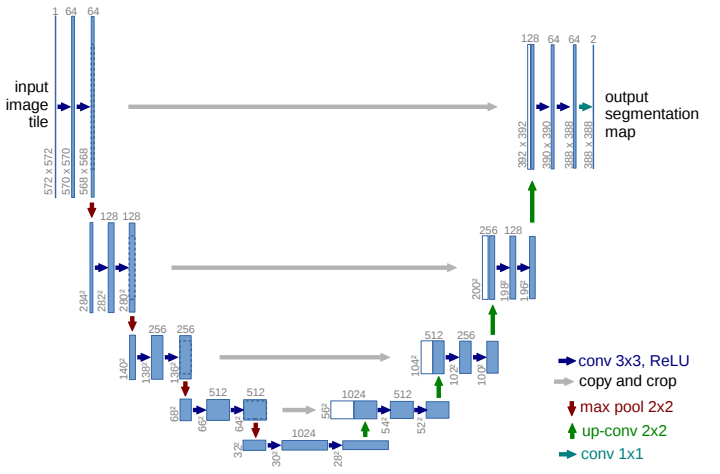

У нас в архитектуре все так же существует энкодер и декодер, как в **SegNet**, но отличительной особеностью данной модели являются *skip-conenctions*, соединяющие части декодера и энкодера. То есть для того чтобы передать на вход декодера тензор, мы конкатенируем симметричный выход с энкодера и выход предыдущего слоя декодера.

* Ronneberger, Olaf, Philipp Fischer, and Thomas Brox. "[U-Net: Convolutional networks for biomedical image segmentation.](https://arxiv.org/pdf/1505.04597.pdf)" International Conference on Medical image computing and computer-assisted intervention. Springer, Cham, 2015.

В оригинальной статье авторы не использовали padding внутри модели (это видно по тому, что размеры карты признаков уменьшаются на 2 каждый раз при движении от слоя к слою). При этом размеры входных изображений авторы единоразово увеличили при помощи mirror padding.

В этом домашнем задании вы можете применить альтернативный подход - сохранять размеры карт признаков при помощью padding = 1 во внутренних слоях.  

In [88]:
import torch.nn.functional as F
import torch.nn as nn

Для реализации UNet вы можете написать классы блоков энкодера и декодера отдельно, как мы сделали при реализации SegNet.

In [89]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(DoubleConv, self).__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),

            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.conv(x)


class DownBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(DownBlock, self).__init__()

        self.down = nn.Sequential(
            nn.MaxPool2d(kernel_size=2, stride=2),
            DoubleConv(in_channels, out_channels)
        )

    def forward(self, x):
        return self.down(x)


class UpBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(UpBlock, self).__init__()

        self.up = nn.ConvTranspose2d(
            in_channels,
            in_channels // 2,
            kernel_size=2,
            stride=2
        )

        self.conv = DoubleConv(in_channels, out_channels)

    def forward(self, x1, x2):
        x1 = self.up(x1)

        # На всякий случай выравниваем размеры, если вдруг они немного отличаются
        diff_y = x2.size(2) - x1.size(2)
        diff_x = x2.size(3) - x1.size(3)

        x1 = F.pad(
            x1,
            [
                diff_x // 2,
                diff_x - diff_x // 2,
                diff_y // 2,
                diff_y - diff_y // 2
            ]
        )

        # Skip-connection: склеиваем признаки encoder и decoder
        x = torch.cat([x2, x1], dim=1)

        return self.conv(x)


class UNet(nn.Module):
    def __init__(self, n_class=1):
        super().__init__()

        self.inc = DoubleConv(3, 64)

        self.down1 = DownBlock(64, 128)
        self.down2 = DownBlock(128, 256)
        self.down3 = DownBlock(256, 512)
        self.down4 = DownBlock(512, 1024)

        self.up1 = UpBlock(1024, 512)
        self.up2 = UpBlock(512, 256)
        self.up3 = UpBlock(256, 128)
        self.up4 = UpBlock(128, 64)

        self.outc = nn.Conv2d(64, n_class, kernel_size=1)

    def forward(self, x):
        x1 = self.inc(x)

        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x5 = self.down4(x4)

        x = self.up1(x5, x4)
        x = self.up2(x, x3)
        x = self.up3(x, x2)
        x = self.up4(x, x1)

        output = self.outc(x)

        return output

In [90]:
unet_model = UNet().to(device)

x_test = torch.randn(2, 3, 256, 256).to(device)
out = unet_model(x_test)

print(out.shape)

torch.Size([2, 1, 256, 256])


## Обучите UNet

Задание: обучите UNet на всех трех лоссах: BCE, Dice, Focal и сравните результаты с SegNet:
*   Какая модель дает лучшие значения по метрике?
*   Какая модель дает лучшие значения по лоссам?
*   Какая модель обучается быстрее?
*   Сравните визуально результаты SegNet и UNet.

Напишите развернутый ответ на вопросы.



По результатам эксперимента лучшую метрику показала модель U-Net, обученная на BCE Loss. На последней эпохе она получила valid_iou = 0.7044, что выше результата SegNet на BCE Loss, где valid_iou = 0.4449. Это можно объяснить тем, что U-Net использует skip-connections: признаки из encoder передаются в decoder, поэтому модель лучше восстанавливает пространственную информацию и границы сегментируемых объектов.

Если сравнивать U-Net на разных функциях потерь, то BCE Loss показал лучший результат по метрике IoU: valid_iou = 0.7044. Dice Loss дал valid_iou = 0.5018, а Focal Loss — valid_iou = 0.3957. Следовательно, в данном эксперименте BCE Loss оказался наиболее эффективным для обучения U-Net.

По значениям loss напрямую сравнивать BCE, Dice и Focal не совсем корректно, потому что это разные функции потерь с разной шкалой значений. Например, у Focal Loss значение valid_loss может быть меньше, но это не означает, что качество сегментации лучше. Поэтому для выбора лучшей модели важнее смотреть на IoU.

Быстрее по времени одна эпоха обучалась примерно одинаково: у U-Net время эпохи составляло около 7–8 секунд, у SegNet — около 5–6 секунд. Поэтому SegNet немного быстрее, но по качеству сегментации U-Net оказался лучше.

Визуально U-Net должен давать более точные маски, потому что благодаря skip-connections decoder получает информацию о деталях изображения из encoder. SegNet восстанавливает изображение через unpooling, но может хуже передавать мелкие детали и границы объектов. Поэтому в данной задаче U-Net можно считать лучшей моделью по качеству, а SegNet — более простой и немного более быстрой базовой моделью.


Обучи U-Net на BCE Loss


In [91]:
unet_bce_model = UNet().to(device)

optimizer = optim.Adam(unet_bce_model.parameters(), lr=1e-4)

unet_bce_history = train(
    model=unet_bce_model,
    train_dataloader=train_dataloader,
    valid_dataloader=valid_dataloader,
    loss_fn=bce_loss,
    optimizer=optimizer,
    epochs=10,
    device=device
)

Epoch 1/10 train:   0%|          | 0/4 [00:00<?, ?it/s]

Epoch 1/10 valid:   0%|          | 0/2 [00:00<?, ?it/s]

Epoch 1/10 | train_loss: 0.5645 | valid_loss: 0.6756 | train_iou: 0.4824 | valid_iou: 0.0000 | time: 8.0s


Epoch 2/10 train:   0%|          | 0/4 [00:00<?, ?it/s]

Epoch 2/10 valid:   0%|          | 0/2 [00:00<?, ?it/s]

...

Epoch 9/10 valid:   0%|          | 0/2 [00:00<?, ?it/s]

Epoch 9/10 | train_loss: 0.2626 | valid_loss: 0.3771 | train_iou: 0.8194 | valid_iou: 0.5512 | time: 7.2s


Epoch 10/10 train:   0%|          | 0/4 [00:00<?, ?it/s]

Epoch 10/10 valid:   0%|          | 0/2 [00:00<?, ?it/s]

Epoch 10/10 | train_loss: 0.2361 | valid_loss: 0.3194 | train_iou: 0.8491 | valid_iou: 0.7044 | time: 7.4s


Обучи U-Net на Dice Loss

In [92]:
unet_dice_model = UNet().to(device)

optimizer = optim.Adam(unet_dice_model.parameters(), lr=1e-4)

unet_dice_history = train(
    model=unet_dice_model,
    train_dataloader=train_dataloader,
    valid_dataloader=valid_dataloader,
    loss_fn=lambda logits, masks: dice_loss(logits, masks) * masks.numel(),
    optimizer=optimizer,
    epochs=10,
    device=device
)

Epoch 1/10 train:   0%|          | 0/4 [00:00<?, ?it/s]

Epoch 1/10 valid:   0%|          | 0/2 [00:00<?, ?it/s]

Epoch 1/10 | train_loss: 0.5282 | valid_loss: 0.6220 | train_iou: 0.4305 | valid_iou: 0.2958 | time: 7.5s


Epoch 2/10 train:   0%|          | 0/4 [00:00<?, ?it/s]

Epoch 2/10 valid:   0%|          | 0/2 [00:00<?, ?it/s]

...

Epoch 9/10 valid:   0%|          | 0/2 [00:00<?, ?it/s]

Epoch 9/10 | train_loss: 0.2880 | valid_loss: 0.5914 | train_iou: 0.7746 | valid_iou: 0.2291 | time: 7.2s


Epoch 10/10 train:   0%|          | 0/4 [00:00<?, ?it/s]

Epoch 10/10 valid:   0%|          | 0/2 [00:00<?, ?it/s]

Epoch 10/10 | train_loss: 0.2881 | valid_loss: 0.4668 | train_iou: 0.7850 | valid_iou: 0.5018 | time: 7.5s


Обучи U-Net на Focal Loss

In [93]:
unet_focal_model = UNet().to(device)

optimizer = optim.Adam(unet_focal_model.parameters(), lr=1e-4)

unet_focal_history = train(
    model=unet_focal_model,
    train_dataloader=train_dataloader,
    valid_dataloader=valid_dataloader,
    loss_fn=lambda logits, masks: focal_loss(masks, logits),
    optimizer=optimizer,
    epochs=10,
    device=device
)

Epoch 1/10 train:   0%|          | 0/4 [00:00<?, ?it/s]

Epoch 1/10 valid:   0%|          | 0/2 [00:00<?, ?it/s]

Epoch 1/10 | train_loss: 0.1728 | valid_loss: 0.1627 | train_iou: 0.4146 | valid_iou: 0.0000 | time: 7.5s


Epoch 2/10 train:   0%|          | 0/4 [00:00<?, ?it/s]

Epoch 2/10 valid:   0%|          | 0/2 [00:00<?, ?it/s]

...

Epoch 9/10 valid:   0%|          | 0/2 [00:00<?, ?it/s]

Epoch 9/10 | train_loss: 0.0454 | valid_loss: 0.1634 | train_iou: 0.8374 | valid_iou: 0.1607 | time: 7.5s


Epoch 10/10 train:   0%|          | 0/4 [00:00<?, ?it/s]

Epoch 10/10 valid:   0%|          | 0/2 [00:00<?, ?it/s]

Epoch 10/10 | train_loss: 0.0476 | valid_loss: 0.1333 | train_iou: 0.8346 | valid_iou: 0.3957 | time: 7.4s
